# Task 4 - Unveiling the Android App Market

## Google Play Store Analysis

### Objective
Perform a comprehensive analysis of Google Play Store applications and user reviews by cleaning the data, exploring app categories, ratings, pricing, installations, and user sentiment.

### Tech Stack
Python, Pandas, NumPy, Matplotlib, Seaborn, Plotly, VADER, Jupyter Notebook

In [1]:
import sys

print(sys.executable)

c:\Users\anule\OneDrive\Documents\OASIS INFOBYTE\Task 4 - Unveiling the Android App Market\.venv\Scripts\python.exe


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Loading the Datasets

Two datasets are used in this project:

1. Google Play Store application data
2. Google Play Store user review data

The datasets are loaded separately so that app-level and review-level analyses can be performed independently before combining information where required.

In [3]:
apps_path = "../data/raw/googleplaystore.csv"
reviews_path = "../data/raw/googleplaystore_user_reviews.csv"

apps = pd.read_csv(apps_path)
reviews = pd.read_csv(reviews_path)

print("Apps dataset shape:", apps.shape)
print("Reviews dataset shape:", reviews.shape)

Apps dataset shape: (10841, 13)
Reviews dataset shape: (64295, 5)


## 2. Initial Exploration of App Data

In [4]:
apps.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [5]:
apps.tail()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device
10840,iHoroscope - 2018 Daily Horoscope & Astrology,LIFESTYLE,4.5,398307,19M,"10,000,000+",Free,0,Everyone,Lifestyle,"July 25, 2018",Varies with device,Varies with device


In [6]:
apps.info()

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.1 MB


In [7]:
apps.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
App,10841,9660,ROBLOX,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,10841,34,FAMILY,1972,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rating,9367.0,NaN,NaN,NaN,4.193338,0.537431,1.0,4.0,4.3,4.5,19.0
Reviews,10841,6002,0,596,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Size,10841,462,Varies with device,1695,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Installs,10841,22,"1,000,000+",1579,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type,10840,3,Free,10039,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,10841,93,0,10040,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Content Rating,10840,6,Everyone,8714,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Genres,10841,120,Tools,842,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
apps.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='str')

## 3. Initial Exploration of User Reviews

In [9]:
reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [10]:
reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  str    
 1   Translated_Review       37427 non-null  str    
 2   Sentiment               37432 non-null  str    
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), str(3)
memory usage: 2.5 MB


In [11]:
reviews.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
App,64295,1074,Angry Birds Classic,320,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Translated_Review,37427,27994,Good,247,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sentiment,37432,3,Positive,23998,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sentiment_Polarity,37432.0,NaN,NaN,NaN,0.182146,0.351301,-1.0,0.0,0.15,0.4,1.0
Sentiment_Subjectivity,37432.0,NaN,NaN,NaN,0.492704,0.259949,0.0,0.357143,0.514286,0.65,1.0


In [12]:
reviews.columns

Index(['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity',
       'Sentiment_Subjectivity'],
      dtype='str')

## 4. Data Cleaning

The raw Google Play Store data contains several real-world data quality issues.

The cleaning process includes:

- Removing duplicate app records
- Handling missing values
- Converting numeric columns stored as text
- Cleaning install counts
- Cleaning prices
- Converting app size to MB
- Converting review counts to numeric values
- Converting dates to datetime format
- Handling malformed records

In [13]:
print("Missing values in apps:")
display(apps.isnull().sum())

print("\nMissing values in reviews:")
display(reviews.isnull().sum())

Missing values in apps:


App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64


Missing values in reviews:


App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64

In [14]:
print("Duplicate app rows before cleaning:", apps.duplicated().sum())
print("Duplicate review rows before cleaning:", reviews.duplicated().sum())

Duplicate app rows before cleaning: 483
Duplicate review rows before cleaning: 33616


In [15]:
apps = apps.drop_duplicates().copy()
reviews = reviews.drop_duplicates().copy()

print("Duplicate app rows after cleaning:", apps.duplicated().sum())
print("Duplicate review rows after cleaning:", reviews.duplicated().sum())

Duplicate app rows after cleaning: 0
Duplicate review rows after cleaning: 0


In [16]:
apps["Rating"] = pd.to_numeric(apps["Rating"], errors="coerce")
apps["Reviews"] = pd.to_numeric(apps["Reviews"], errors="coerce")

apps["Installs"] = (
    apps["Installs"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)

apps["Installs"] = pd.to_numeric(apps["Installs"], errors="coerce")

apps["Price"] = (
    apps["Price"]
    .astype(str)
    .str.replace("$", "", regex=False)
)

apps["Price"] = pd.to_numeric(apps["Price"], errors="coerce")

In [17]:
apps[["App", "Category", "Rating", "Reviews", "Installs", "Price"]].head(10)

,App,Category,Rating,Reviews,Installs,Price
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,10000.0,0.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,500000.0,0.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,5000000.0,0.0
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,50000000.0,0.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,100000.0,0.0
5,Paper flowers instructions,ART_AND_DESIGN,4.4,167.0,50000.0,0.0
6,Smoke Effect Photo Maker - Smoke Editor,ART_AND_DESIGN,3.8,178.0,50000.0,0.0
7,Infinite Painter,ART_AND_DESIGN,4.1,36815.0,1000000.0,0.0
8,Garden Coloring Book,ART_AND_DESIGN,4.4,13791.0,1000000.0,0.0
9,Kids Paint Free - Drawing Fun,ART_AND_DESIGN,4.7,121.0,10000.0,0.0


In [18]:
def convert_size_to_mb(value):
    if pd.isna(value):
        return np.nan
    
    value = str(value).strip()
    
    if value == "Varies with device":
        return np.nan
    
    if value.endswith("M"):
        return float(value[:-1])
    
    if value.endswith("k"):
        return float(value[:-1]) / 1024
    
    return np.nan


apps["Size_MB"] = apps["Size"].apply(convert_size_to_mb)

In [19]:
apps[["Size", "Size_MB"]].head(20)

,Size,Size_MB
0,19M,19.0
1,14M,14.0
2,8.7M,8.7
3,25M,25.0
4,2.8M,2.8
5,5.6M,5.6
6,19M,19.0
7,29M,29.0
8,33M,33.0
9,3.1M,3.1


In [20]:
apps["Last Updated"] = pd.to_datetime(
    apps["Last Updated"],
    errors="coerce"
)

apps["Last_Updated_Year"] = apps["Last Updated"].dt.year
apps["Last_Updated_Month"] = apps["Last Updated"].dt.month

In [21]:
apps[["Last Updated", "Last_Updated_Year", "Last_Updated_Month"]].head()

,Last Updated,Last_Updated_Year,Last_Updated_Month
0,2018-01-07,2018.0,1.0
1,2018-01-15,2018.0,1.0
2,2018-08-01,2018.0,8.0
3,2018-06-08,2018.0,6.0
4,2018-06-20,2018.0,6.0


In [22]:
apps["Rating"].isna().sum()

np.int64(1465)

In [23]:
apps["Category"] = apps["Category"].fillna("Unknown")
apps["Type"] = apps["Type"].fillna("Unknown")
apps["Content Rating"] = apps["Content Rating"].fillna("Unknown")
apps["Genres"] = apps["Genres"].fillna("Unknown")

In [24]:
reviews["Translated_Review"] = reviews["Translated_Review"].fillna("")

## 5. Cleaned Dataset Validation

In [25]:
apps.info()

<class 'pandas.DataFrame'>
Index: 10358 entries, 0 to 10840
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   App                 10358 non-null  str           
 1   Category            10358 non-null  str           
 2   Rating              8893 non-null   float64       
 3   Reviews             10357 non-null  float64       
 4   Size                10358 non-null  str           
 5   Installs            10357 non-null  float64       
 6   Type                10358 non-null  str           
 7   Price               10357 non-null  float64       
 8   Content Rating      10358 non-null  str           
 9   Genres              10358 non-null  str           
 10  Last Updated        10357 non-null  datetime64[us]
 11  Current Ver         10350 non-null  str           
 12  Android Ver         10355 non-null  str           
 13  Size_MB             8831 non-null   float64       
 14  Last_U

In [26]:
apps.describe().T

,count,mean,min,25%,50%,75%,max,std
Rating,8893.0,4.189542,1.0,4.0,4.3,4.5,19.0,0.545452
Reviews,10357.0,405904.610602,0.0,32.0,1680.0,46416.0,78158306.0,2696777.836748
Installs,10357.0,14157759.440668,0.0,1000.0,100000.0,1000000.0,1000000000.0,80239553.869019
Price,10357.0,1.0308,0.0,0.0,0.0,0.0,400.0,16.278625
Last Updated,10357,2017-11-14 09:25:19.320266,2010-05-21 00:00:00,2017-09-03 00:00:00,2018-05-20 00:00:00,2018-07-19 00:00:00,2018-08-08 00:00:00,NaN
Size_MB,8831.0,21.287413,0.008301,4.7,13.0,29.0,100.0,22.540591
Last_Updated_Year,10357.0,2017.382929,2010.0,2017.0,2018.0,2018.0,2018.0,1.112766
Last_Updated_Month,10357.0,6.397026,1.0,5.0,7.0,8.0,12.0,2.606359


In [27]:
reviews.info()

<class 'pandas.DataFrame'>
Index: 30679 entries, 0 to 64236
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     30679 non-null  str    
 1   Translated_Review       30679 non-null  str    
 2   Sentiment               29697 non-null  str    
 3   Sentiment_Polarity      29697 non-null  float64
 4   Sentiment_Subjectivity  29697 non-null  float64
dtypes: float64(2), str(3)
memory usage: 1.4 MB


## 6. App Category Analysis

This section examines how applications are distributed across Google Play Store categories.

In [28]:
category_counts = apps["Category"].value_counts()

display(category_counts)

Category
FAMILY                 1943
GAME                   1121
TOOLS                   843
BUSINESS                427
MEDICAL                 408
PRODUCTIVITY            407
PERSONALIZATION         388
LIFESTYLE               373
COMMUNICATION           366
FINANCE                 360
SPORTS                  351
PHOTOGRAPHY             322
HEALTH_AND_FITNESS      306
SOCIAL                  280
NEWS_AND_MAGAZINES      264
TRAVEL_AND_LOCAL        237
BOOKS_AND_REFERENCE     230
SHOPPING                224
DATING                  196
VIDEO_PLAYERS           175
MAPS_AND_NAVIGATION     137
EDUCATION               130
FOOD_AND_DRINK          124
ENTERTAINMENT           111
AUTO_AND_VEHICLES        85
LIBRARIES_AND_DEMO       85
WEATHER                  82
HOUSE_AND_HOME           80
ART_AND_DESIGN           65
EVENTS                   64
COMICS                   60
PARENTING                60
BEAUTY                   53
1.9                       1
Name: count, dtype: int64

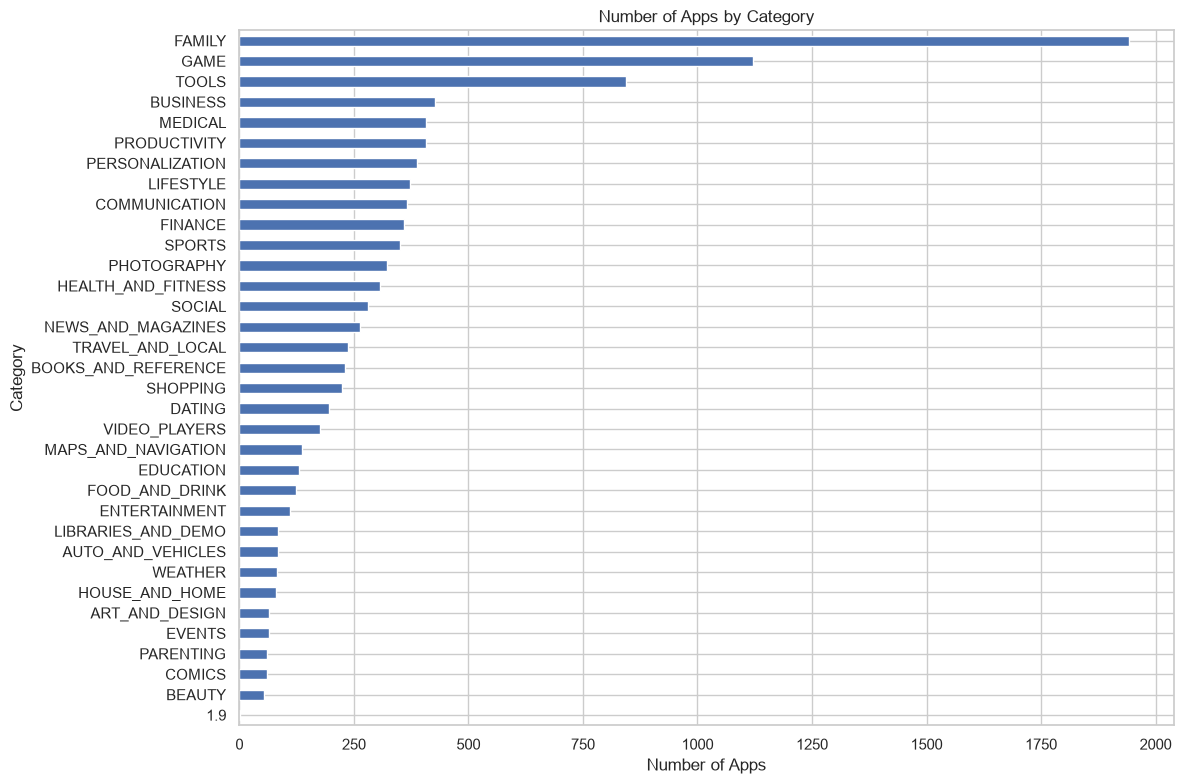

In [29]:
plt.figure(figsize=(12, 8))

category_counts.sort_values().plot(
    kind="barh",
    figsize=(12, 8)
)

plt.title("Number of Apps by Category")
plt.xlabel("Number of Apps")
plt.ylabel("Category")

plt.tight_layout()
plt.savefig("../images/app_distribution_by_category.png", dpi=300)
plt.show()

### Observation

The category distribution shows that app development is not evenly distributed across the Google Play Store. Some categories contain substantially more applications than others, indicating differences in developer activity and market concentration.

In [30]:
top_categories = category_counts.head(10)

display(top_categories)

Category
FAMILY             1943
GAME               1121
TOOLS               843
BUSINESS            427
MEDICAL             408
PRODUCTIVITY        407
PERSONALIZATION     388
LIFESTYLE           373
COMMUNICATION       366
FINANCE             360
Name: count, dtype: int64

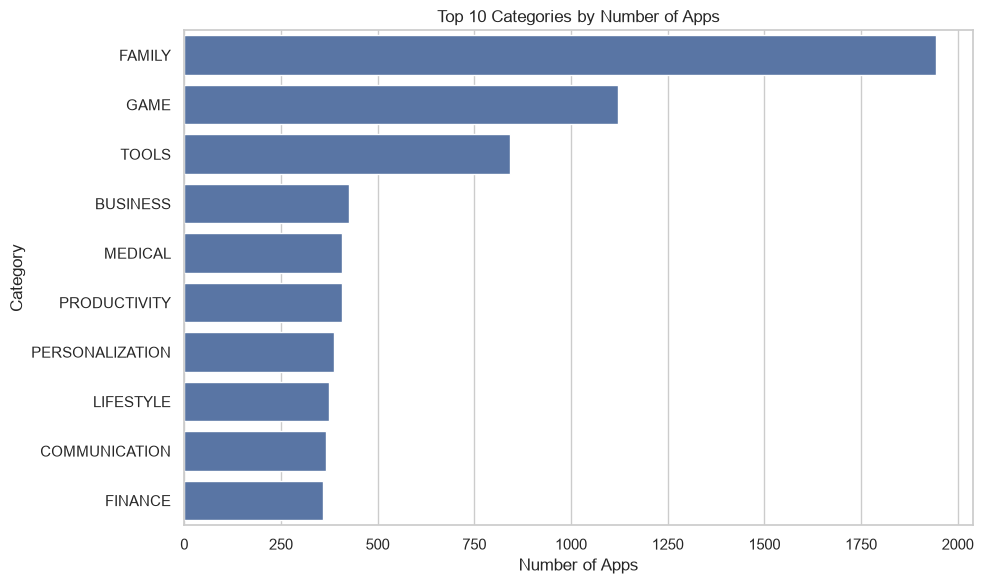

In [32]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_categories.values,
    y=top_categories.index
)

plt.title("Top 10 Categories by Number of Apps")
plt.xlabel("Number of Apps")
plt.ylabel("Category")

plt.tight_layout()
plt.savefig("../images/top_10_categories.png", dpi=300)
plt.show()

## 7. Ratings Analysis

This section analyzes the distribution of app ratings and compares average ratings across categories.

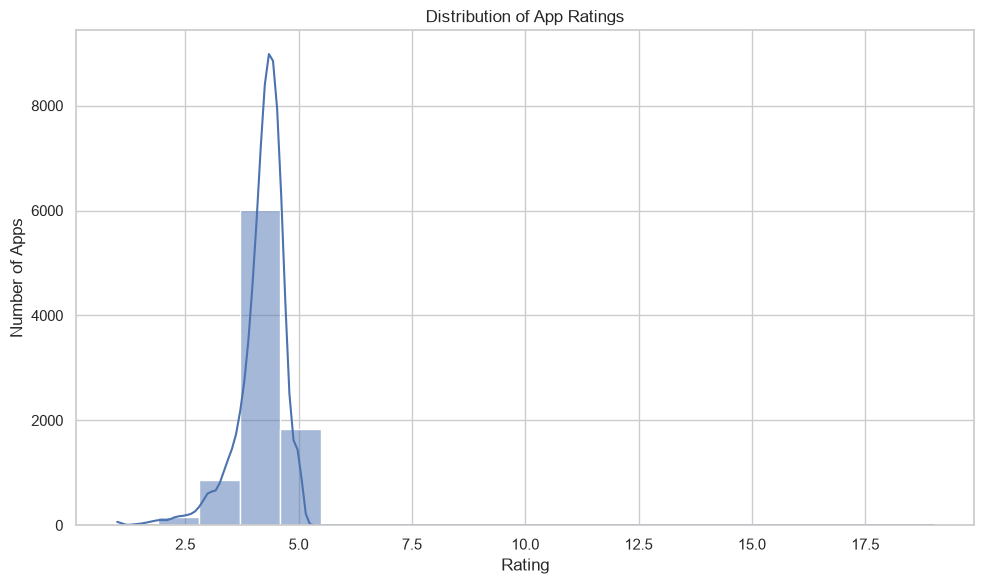

In [33]:
plt.figure(figsize=(10, 6))

sns.histplot(
    apps["Rating"].dropna(),
    bins=20,
    kde=True
)

plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Apps")

plt.tight_layout()
plt.savefig("../images/rating_distribution.png", dpi=300)
plt.show()

In [34]:
category_rating = (
    apps.groupby("Category")["Rating"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

display(category_rating)

,mean,count
Category,,
1.9,19.000000,1
EVENTS,4.435556,45
EDUCATION,4.375969,129
ART_AND_DESIGN,4.358065,62
BOOKS_AND_REFERENCE,4.347458,177
PERSONALIZATION,4.333871,310
PARENTING,4.300000,50
GAME,4.281285,1074
BEAUTY,4.278571,42


In [35]:
category_rating_20 = (
    apps.groupby("Category")["Rating"]
    .agg(["mean", "count"])
    .query("count >= 20")
    .sort_values("mean", ascending=False)
)

display(category_rating_20.head(10))

,mean,count
Category,,
EVENTS,4.435556,45
EDUCATION,4.375969,129
ART_AND_DESIGN,4.358065,62
BOOKS_AND_REFERENCE,4.347458,177
PERSONALIZATION,4.333871,310
PARENTING,4.300000,50
GAME,4.281285,1074
BEAUTY,4.278571,42
HEALTH_AND_FITNESS,4.261450,262


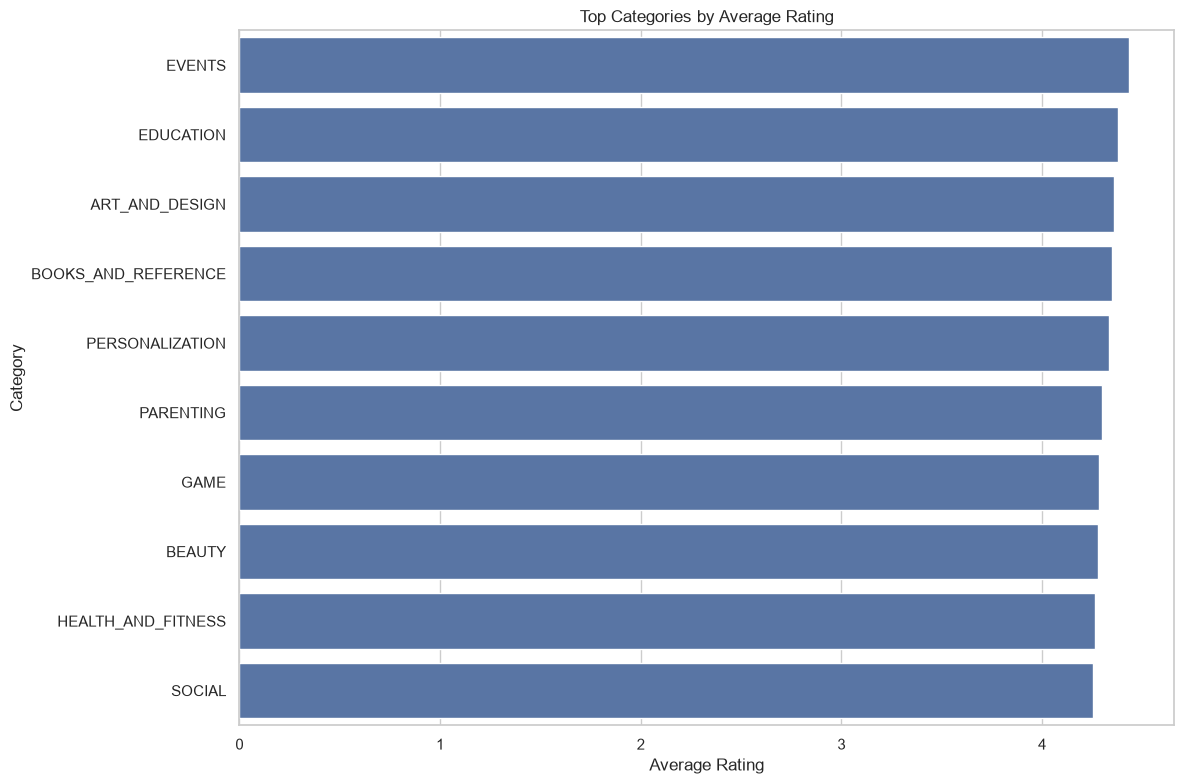

In [37]:
plt.figure(figsize=(12, 8))

sns.barplot(
    data=category_rating_20.head(10).reset_index(),
    x="mean",
    y="Category"
)

plt.title("Top Categories by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Category")

plt.tight_layout()
plt.savefig("../images/average_rating_by_category.png", dpi=300)
plt.show()

### Observation

Average ratings vary across categories. However, average rating should be interpreted together with the number of rated apps because categories with very few observations may produce unstable averages.

## 8. App Size and Install Analysis

This section investigates whether app size is associated with the number of installations.

In [38]:
size_install_data = apps[
    ["App", "Size_MB", "Installs", "Rating", "Category"]
].dropna()

size_install_data.head()

,App,Size_MB,Installs,Rating,Category
0,Photo Editor & Candy Camera & Grid & ScrapBook,19.0,10000.0,4.1,ART_AND_DESIGN
1,Coloring book moana,14.0,500000.0,3.9,ART_AND_DESIGN
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",8.7,5000000.0,4.7,ART_AND_DESIGN
3,Sketch - Draw & Paint,25.0,50000000.0,4.5,ART_AND_DESIGN
4,Pixel Draw - Number Art Coloring Book,2.8,100000.0,4.3,ART_AND_DESIGN


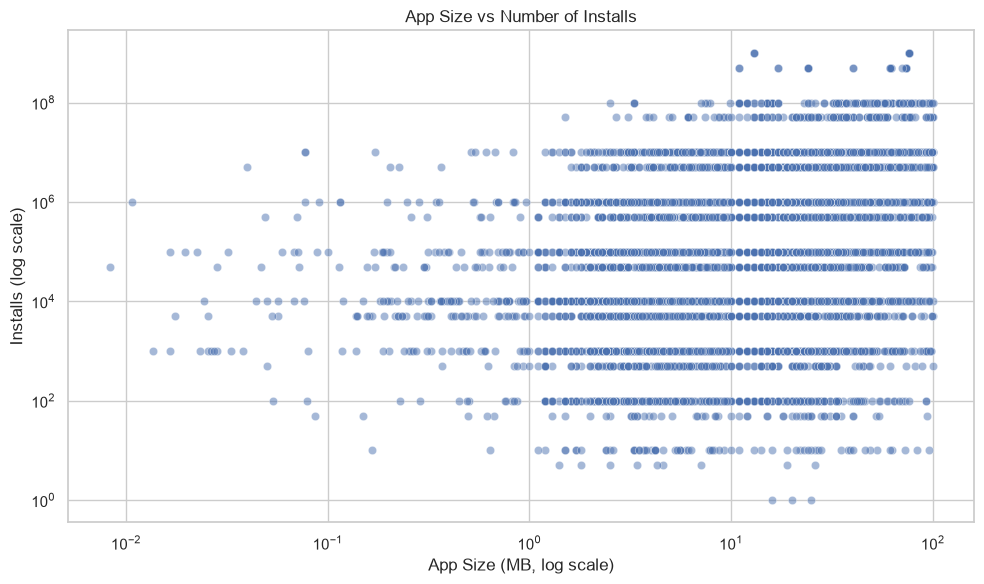

In [39]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=size_install_data,
    x="Size_MB",
    y="Installs",
    alpha=0.5
)

plt.xscale("log")
plt.yscale("log")

plt.title("App Size vs Number of Installs")
plt.xlabel("App Size (MB, log scale)")
plt.ylabel("Installs (log scale)")

plt.tight_layout()
plt.savefig("../images/size_vs_installs.png", dpi=300)
plt.show()

In [40]:
correlation = size_install_data["Size_MB"].corr(
    size_install_data["Installs"]
)

print("Correlation between app size and installs:", correlation)

Correlation between app size and installs: 0.16703215756090944


In [41]:
size_install_data["log_size"] = np.log1p(size_install_data["Size_MB"])
size_install_data["log_installs"] = np.log1p(size_install_data["Installs"])

log_correlation = size_install_data["log_size"].corr(
    size_install_data["log_installs"]
)

print("Correlation after log transformation:", log_correlation)

Correlation after log transformation: 0.3517574102012014


### Observation

The correlation between app size and installations should be interpreted carefully. A correlation value close to zero indicates little linear association, while positive or negative values indicate the direction and strength of the linear relationship. Correlation alone does not establish causation.

## 9. Pricing Analysis

This section compares free and paid applications and examines the distribution of paid-app prices.

In [42]:
type_counts = apps["Type"].value_counts()

display(type_counts)

Type
Free       9591
Paid        765
Unknown       1
0             1
Name: count, dtype: int64

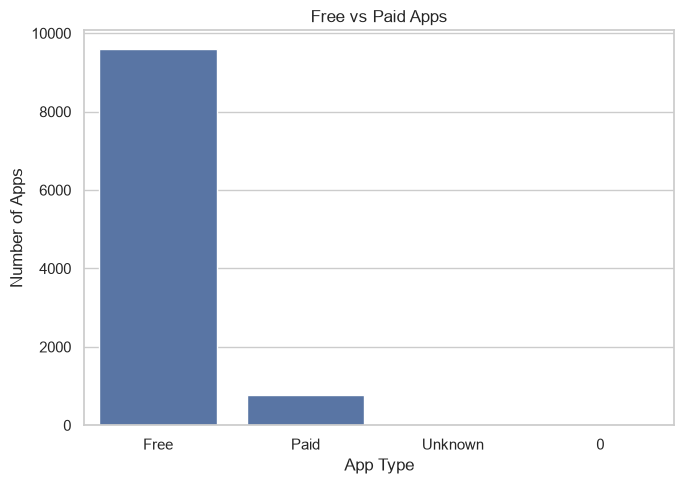

In [43]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=apps,
    x="Type"
)

plt.title("Free vs Paid Apps")
plt.xlabel("App Type")
plt.ylabel("Number of Apps")

plt.tight_layout()
plt.savefig("../images/free_vs_paid.png", dpi=300)
plt.show()

In [44]:
paid_apps = apps[
    (apps["Type"] == "Paid") &
    (apps["Price"] > 0)
].copy()

print("Number of paid apps:", len(paid_apps))

Number of paid apps: 765


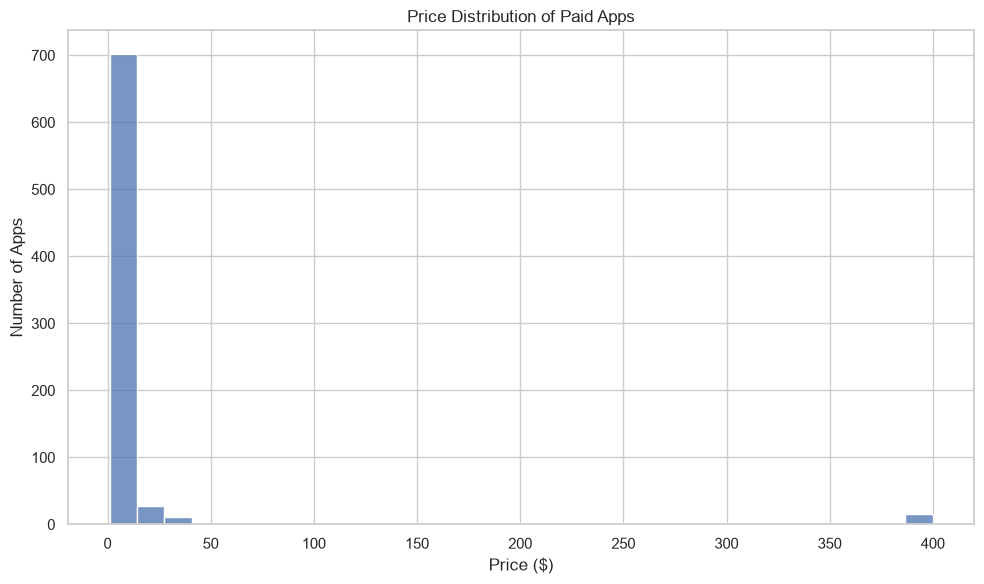

In [45]:
plt.figure(figsize=(10, 6))

sns.histplot(
    paid_apps["Price"],
    bins=30
)

plt.title("Price Distribution of Paid Apps")
plt.xlabel("Price ($)")
plt.ylabel("Number of Apps")

plt.tight_layout()
plt.savefig("../images/paid_app_price_distribution.png", dpi=300)
plt.show()

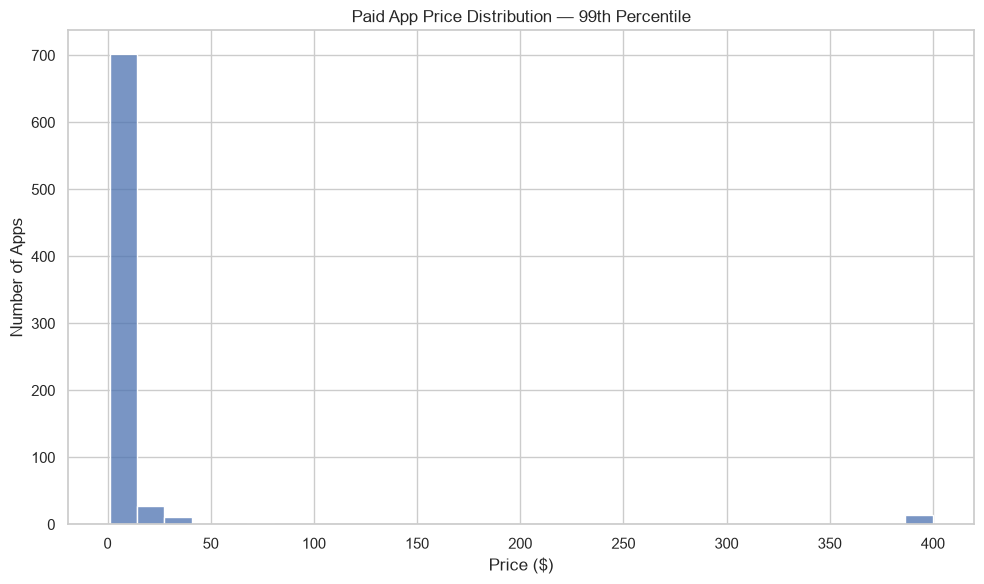

In [47]:
paid_apps_reasonable = paid_apps[
    paid_apps["Price"] <= paid_apps["Price"].quantile(0.99)
]

plt.figure(figsize=(10, 6))

sns.histplot(
    paid_apps_reasonable["Price"],
    bins=30
)

plt.title("Paid App Price Distribution — 99th Percentile")
plt.xlabel("Price ($)")
plt.ylabel("Number of Apps")

plt.tight_layout()
plt.show()

In [48]:
paid_apps["Estimated_Revenue"] = (
    paid_apps["Price"] * paid_apps["Installs"]
)

In [49]:
paid_apps[
    ["App", "Category", "Price", "Installs", "Estimated_Revenue"]
].sort_values(
    "Estimated_Revenue",
    ascending=False
).head(10)

,App,Category,Price,Installs,Estimated_Revenue
2241,Minecraft,FAMILY,6.99,10000000.0,69900000.0
4347,Minecraft,FAMILY,6.99,10000000.0,69900000.0
5351,I am rich,LIFESTYLE,399.99,100000.0,39999000.0
5356,I Am Rich Premium,FINANCE,399.99,50000.0,19999500.0
4034,Hitman Sniper,GAME,0.99,10000000.0,9900000.0
7417,Grand Theft Auto: San Andreas,GAME,6.99,1000000.0,6990000.0
2883,Facetune - For Free,PHOTOGRAPHY,5.99,1000000.0,5990000.0
5578,Sleep as Android Unlock,LIFESTYLE,5.99,1000000.0,5990000.0
8804,DraStic DS Emulator,GAME,4.99,1000000.0,4990000.0
4367,I'm Rich - Trump Edition,LIFESTYLE,400.00,10000.0,4000000.0


In [52]:
category_revenue = (
    paid_apps.groupby("Category")["Estimated_Revenue"]
    .sum()
    .sort_values(ascending=False)
)

display(category_revenue.head(10))

Category
FAMILY             1.857803e+08
LIFESTYLE          5.758394e+07
GAME               4.098764e+07
FINANCE            2.572668e+07
PHOTOGRAPHY        8.942768e+06
MEDICAL            8.456536e+06
PERSONALIZATION    7.786948e+06
TOOLS              5.464821e+06
SPORTS             4.706212e+06
PRODUCTIVITY       4.313375e+06
Name: Estimated_Revenue, dtype: float64

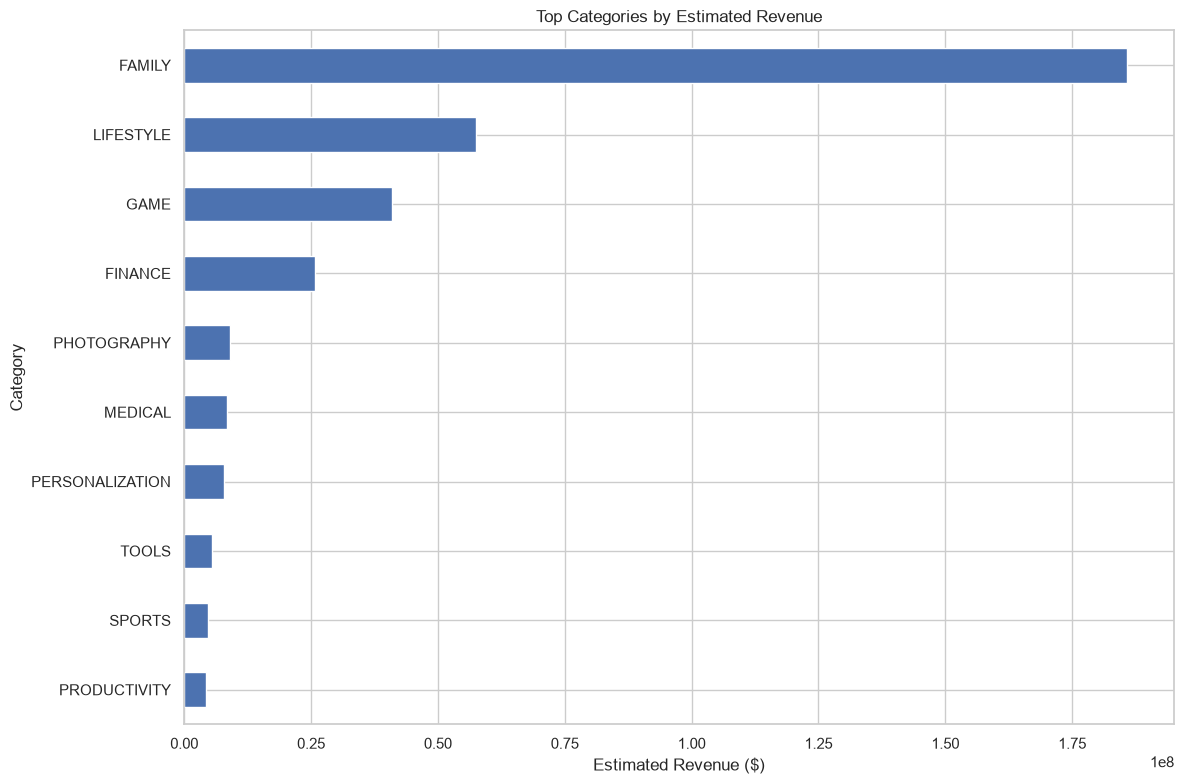

In [53]:
plt.figure(figsize=(12, 8))

category_revenue.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top Categories by Estimated Revenue")
plt.xlabel("Estimated Revenue ($)")
plt.ylabel("Category")

plt.tight_layout()
plt.savefig("../images/revenue_by_category.png", dpi=300)
plt.show()

### Observation

Estimated revenue is concentrated among categories containing paid applications with comparatively high installation counts and prices. The calculation represents a simple gross-revenue proxy rather than actual developer earnings.

## 10. User Review Cleaning

The review dataset contains user-written text. Empty reviews are removed before sentiment classification.

In [54]:
reviews_clean = reviews.copy()

reviews_clean["Translated_Review"] = (
    reviews_clean["Translated_Review"]
    .astype(str)
    .str.strip()
)

reviews_clean = reviews_clean[
    reviews_clean["Translated_Review"].ne("")
].copy()

print("Reviews before cleaning:", len(reviews))
print("Reviews after cleaning:", len(reviews_clean))

Reviews before cleaning: 30679
Reviews after cleaning: 29692


## 11. Sentiment Analysis Using VADER

VADER is used to classify user reviews into:

- Positive
- Negative
- Neutral

The compound sentiment score is used for classification.

In [55]:
analyzer = SentimentIntensityAnalyzer()

def vader_sentiment(text):
    score = analyzer.polarity_scores(text)["compound"]
    
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"


reviews_clean["VADER_Sentiment"] = (
    reviews_clean["Translated_Review"]
    .apply(vader_sentiment)
)

In [56]:
reviews_clean["VADER_Compound"] = (
    reviews_clean["Translated_Review"]
    .apply(
        lambda x: analyzer.polarity_scores(x)["compound"]
    )
)

In [57]:
reviews_clean[
    ["Translated_Review", "VADER_Compound", "VADER_Sentiment"]
].head(20)

,Translated_Review,VADER_Compound,VADER_Sentiment
0,I like eat delicious food. That's I'm cooking ...,0.9531,Positive
1,This help eating healthy exercise regular basis,0.6597,Positive
3,Works great especially going grocery store,0.6249,Positive
4,Best idea us,0.6369,Positive
5,Best way,0.6369,Positive
6,Amazing,0.5859,Positive
8,"Looking forward app,",0.0000,Neutral
9,It helpful site ! It help foods get !,0.7256,Positive
10,good you.,0.4404,Positive
11,Useful information The amount spelling errors ...,0.4404,Positive


In [58]:
sentiment_counts = reviews_clean["VADER_Sentiment"].value_counts()

display(sentiment_counts)

VADER_Sentiment
Positive    20197
Negative     5866
Neutral      3629
Name: count, dtype: int64

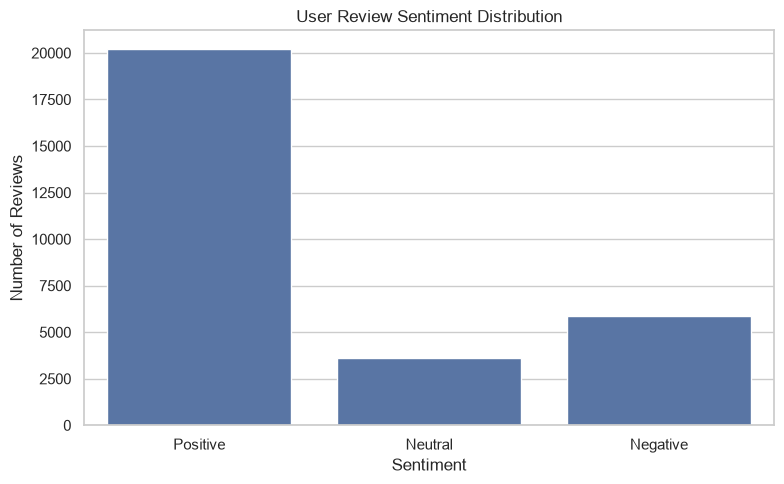

In [59]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=reviews_clean,
    x="VADER_Sentiment",
    order=["Positive", "Neutral", "Negative"]
)

plt.title("User Review Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.savefig("../images/sentiment_distribution.png", dpi=300)
plt.show()

In [60]:
sentiment_percentage = (
    reviews_clean["VADER_Sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(sentiment_percentage)

VADER_Sentiment
Positive    68.02
Negative    19.76
Neutral     12.22
Name: proportion, dtype: float64

In [61]:
review_category = reviews_clean.merge(
    apps[["App", "Category"]],
    on="App",
    how="left"
)

print(review_category.shape)

(41856, 8)


In [62]:
sentiment_by_category = pd.crosstab(
    review_category["Category"],
    review_category["VADER_Sentiment"]
)

display(sentiment_by_category.head())

VADER_Sentiment,Negative,Neutral,Positive
Category,,,
ART_AND_DESIGN,47,42,265
AUTO_AND_VEHICLES,14,36,233
BEAUTY,64,62,191
BOOKS_AND_REFERENCE,132,84,495
BUSINESS,142,157,504


In [63]:
sentiment_by_category_pct = (
    pd.crosstab(
        review_category["Category"],
        review_category["VADER_Sentiment"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

display(sentiment_by_category_pct.head(10))

VADER_Sentiment,Negative,Neutral,Positive
Category,,,
ART_AND_DESIGN,13.28,11.86,74.86
AUTO_AND_VEHICLES,4.95,12.72,82.33
BEAUTY,20.19,19.56,60.25
BOOKS_AND_REFERENCE,18.57,11.81,69.62
BUSINESS,17.68,19.55,62.76
COMICS,2.50,8.75,88.75
COMMUNICATION,23.60,12.58,63.82
DATING,23.74,14.93,61.33
EDUCATION,10.04,10.45,79.51


In [64]:
category_review_counts = (
    review_category.groupby("Category")
    .size()
)

valid_categories = category_review_counts[
    category_review_counts >= 50
].index

sentiment_valid = sentiment_by_category_pct.loc[
    sentiment_by_category_pct.index.intersection(valid_categories)
]

In [65]:
most_positive_categories = (
    sentiment_valid["Positive"]
    .sort_values(ascending=False)
    .head(10)
)

display(most_positive_categories)

Category
COMICS                88.75
AUTO_AND_VEHICLES     82.33
EVENTS                80.13
EDUCATION             79.51
HEALTH_AND_FITNESS    77.70
ART_AND_DESIGN        74.86
FOOD_AND_DRINK        74.62
FAMILY                73.92
PARENTING             73.44
GAME                  72.02
Name: Positive, dtype: float64

In [66]:
most_negative_categories = (
    sentiment_valid["Negative"]
    .sort_values(ascending=False)
    .head(10)
)

display(most_negative_categories)

Category
SOCIAL                33.95
VIDEO_PLAYERS         31.90
ENTERTAINMENT         25.95
NEWS_AND_MAGAZINES    24.30
DATING                23.74
COMMUNICATION         23.60
FINANCE               23.53
SPORTS                23.17
GAME                  23.01
TRAVEL_AND_LOCAL      22.44
Name: Negative, dtype: float64

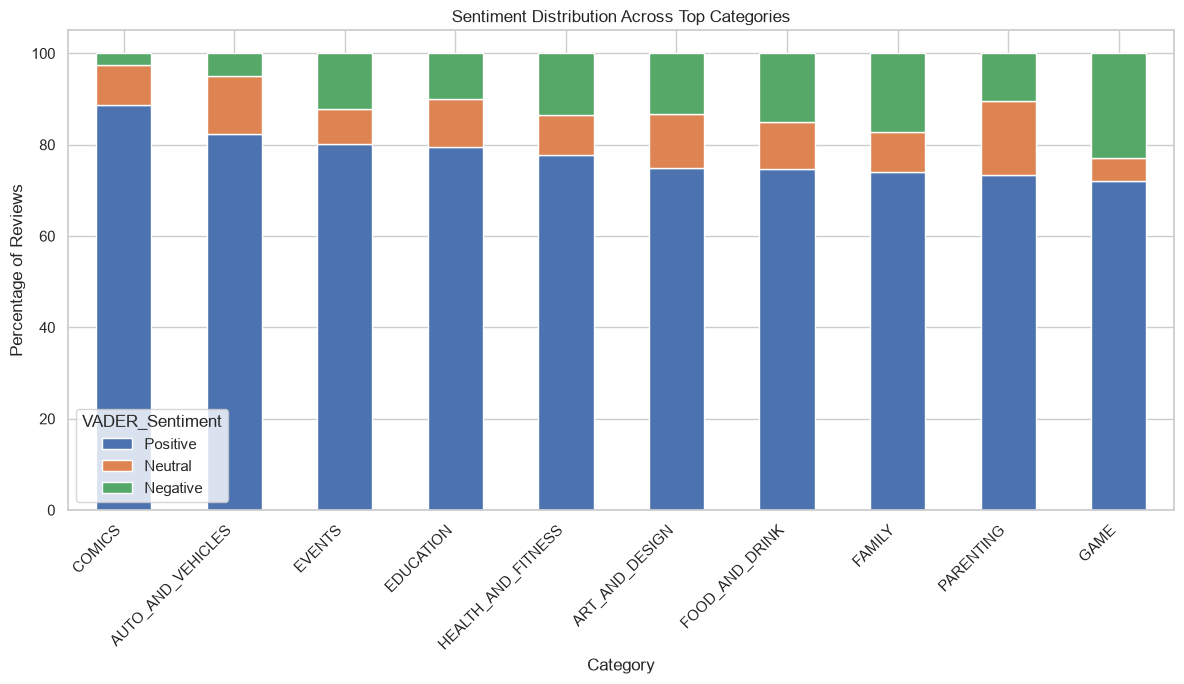

In [67]:
sentiment_plot = sentiment_valid.sort_values(
    "Positive",
    ascending=False
).head(10)

sentiment_plot[["Positive", "Neutral", "Negative"]].plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7)
)

plt.title("Sentiment Distribution Across Top Categories")
plt.xlabel("Category")
plt.ylabel("Percentage of Reviews")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig("../images/sentiment_by_category.png", dpi=300)
plt.show()

In [68]:
category_plotly = (
    apps["Category"]
    .value_counts()
    .reset_index()
)

category_plotly.columns = ["Category", "Number_of_Apps"]

fig = px.bar(
    category_plotly,
    x="Category",
    y="Number_of_Apps",
    title="Interactive Google Play Store App Distribution by Category",
    labels={
        "Category": "App Category",
        "Number_of_Apps": "Number of Apps"
    }
)

fig.update_layout(
    xaxis_tickangle=-45
)

fig.show()

In [69]:
plotly_size_data = size_install_data.copy()

fig = px.scatter(
    plotly_size_data,
    x="Size_MB",
    y="Installs",
    hover_name="App",
    hover_data=["Category", "Rating"],
    log_x=True,
    log_y=True,
    title="Interactive App Size vs Installs"
)

fig.show()

In [70]:
summary = {
    "Total Apps": len(apps),
    "Unique Categories": apps["Category"].nunique(),
    "Average Rating": round(apps["Rating"].mean(), 2),
    "Total Installs": int(apps["Installs"].sum()),
    "Free Apps": int((apps["Type"] == "Free").sum()),
    "Paid Apps": int((apps["Type"] == "Paid").sum()),
    "Total Reviews Analyzed": len(reviews_clean),
    "Positive Reviews": int((reviews_clean["VADER_Sentiment"] == "Positive").sum()),
    "Neutral Reviews": int((reviews_clean["VADER_Sentiment"] == "Neutral").sum()),
    "Negative Reviews": int((reviews_clean["VADER_Sentiment"] == "Negative").sum())
}

summary_df = pd.DataFrame(
    summary.items(),
    columns=["Metric", "Value"]
)

display(summary_df)

,Metric,Value
0,Total Apps,1.035800e+04
1,Unique Categories,3.400000e+01
2,Average Rating,4.190000e+00
3,Total Installs,1.466319e+11
4,Free Apps,9.591000e+03
5,Paid Apps,7.650000e+02
6,Total Reviews Analyzed,2.969200e+04
7,Positive Reviews,2.019700e+04
8,Neutral Reviews,3.629000e+03
9,Negative Reviews,5.866000e+03


In [71]:
top_installed_apps = (
    apps[
        ["App", "Category", "Rating", "Reviews", "Installs", "Type"]
    ]
    .sort_values("Installs", ascending=False)
    .head(10)
)

display(top_installed_apps)

,App,Category,Rating,Reviews,Installs,Type
3454,Google Drive,PRODUCTIVITY,4.4,2731171.0,1.000000e+09,Free
865,Google Play Games,ENTERTAINMENT,4.3,7165362.0,1.000000e+09,Free
3523,Google Drive,PRODUCTIVITY,4.4,2731211.0,1.000000e+09,Free
2544,Facebook,SOCIAL,4.1,78158306.0,1.000000e+09,Free
2545,Instagram,SOCIAL,4.5,66577313.0,1.000000e+09,Free
464,Hangouts,COMMUNICATION,4.0,3419513.0,1.000000e+09,Free
3223,Maps - Navigate & Explore,TRAVEL_AND_LOCAL,4.3,9235373.0,1.000000e+09,Free
3816,Google News,NEWS_AND_MAGAZINES,3.9,877643.0,1.000000e+09,Free
4170,Google Drive,PRODUCTIVITY,4.4,2728941.0,1.000000e+09,Free
3896,Subway Surfers,GAME,4.5,27711703.0,1.000000e+09,Free


In [72]:
top_reviewed_apps = (
    apps[
        ["App", "Category", "Rating", "Reviews", "Installs", "Type"]
    ]
    .sort_values("Reviews", ascending=False)
    .head(10)
)

display(top_reviewed_apps)

,App,Category,Rating,Reviews,Installs,Type
2544,Facebook,SOCIAL,4.1,78158306.0,1.000000e+09,Free
3943,Facebook,SOCIAL,4.1,78128208.0,1.000000e+09,Free
336,WhatsApp Messenger,COMMUNICATION,4.4,69119316.0,1.000000e+09,Free
3904,WhatsApp Messenger,COMMUNICATION,4.4,69109672.0,1.000000e+09,Free
2604,Instagram,SOCIAL,4.5,66577446.0,1.000000e+09,Free
2545,Instagram,SOCIAL,4.5,66577313.0,1.000000e+09,Free
3909,Instagram,SOCIAL,4.5,66509917.0,1.000000e+09,Free
382,Messenger – Text and Video Chat for Free,COMMUNICATION,4.0,56646578.0,1.000000e+09,Free
335,Messenger – Text and Video Chat for Free,COMMUNICATION,4.0,56642847.0,1.000000e+09,Free
1879,Clash of Clans,GAME,4.6,44893888.0,1.000000e+08,Free


In [73]:
top_rated_apps = (
    apps[
        (apps["Reviews"] >= 100)
    ][
        ["App", "Category", "Rating", "Reviews", "Installs"]
    ]
    .sort_values(
        ["Rating", "Reviews"],
        ascending=[False, False]
    )
    .head(10)
)

display(top_rated_apps)

,App,Category,Rating,Reviews,Installs
10357,Ríos de Fe,LIFESTYLE,5.0,141.0,1000.0
10301,"FD Calculator (EMI, SIP, RD & Loan Eligilibility)",FINANCE,5.0,104.0,1000.0
8058,Oración CX,LIFESTYLE,5.0,103.0,5000.0
6823,Barisal University App-BU Face,FAMILY,5.0,100.0,1000.0
9625,JW Library,BOOKS_AND_REFERENCE,4.9,922752.0,10000000.0
1260,Six Pack in 30 Days - Abs Workout,HEALTH_AND_FITNESS,4.9,272337.0,10000000.0
4854,Six Pack in 30 Days - Abs Workout,HEALTH_AND_FITNESS,4.9,272172.0,10000000.0
79,Tickets + PDA 2018 Exam,AUTO_AND_VEHICLES,4.9,197136.0,1000000.0
712,"Learn Japanese, Korean, Chinese Offline & Free",EDUCATION,4.9,133136.0,1000000.0
2344,Period Tracker,MEDICAL,4.9,100082.0,1000000.0


In [74]:
largest_category = category_counts.idxmax()
largest_category_count = category_counts.max()

highest_rated_category = category_rating_20["mean"].idxmax()
highest_rated_value = category_rating_20["mean"].max()

highest_revenue_category = category_revenue.idxmax()
highest_revenue_value = category_revenue.max()

positive_category = most_positive_categories.index[0]
positive_category_value = most_positive_categories.iloc[0]

negative_category = most_negative_categories.index[0]
negative_category_value = most_negative_categories.iloc[0]

print("INSIGHT 1")
print(
    f"{largest_category} has the largest number of apps "
    f"({largest_category_count:,}), indicating substantial developer activity."
)

print("\nINSIGHT 2")
print(
    f"{highest_revenue_category} has the highest estimated revenue "
    f"among paid-app categories, with an estimated gross revenue proxy "
    f"of ${highest_revenue_value:,.0f}."
)

print("\nINSIGHT 3")
print(
    f"{positive_category} has the highest positive-review percentage "
    f"among categories with at least 50 analyzed reviews "
    f"({positive_category_value:.2f}%)."
)

INSIGHT 1
FAMILY has the largest number of apps (1,943), indicating substantial developer activity.

INSIGHT 2
FAMILY has the highest estimated revenue among paid-app categories, with an estimated gross revenue proxy of $185,780,335.

INSIGHT 3
COMICS has the highest positive-review percentage among categories with at least 50 analyzed reviews (88.75%).


# 12. Conclusion

## Key Data-Driven Insights

### 1. Category Distribution
The analysis identifies the most represented app categories in the Google Play Store. The distribution shows that developer activity is concentrated in particular categories rather than being evenly distributed.

### 2. Pricing and Revenue
Free applications make up a substantial portion of the dataset, while paid applications form a smaller segment. Estimated revenue analysis shows that revenue potential depends on the combination of app price and installation volume.

### 3. User Sentiment
VADER-based sentiment analysis shows how positive, neutral, and negative opinions are distributed across user reviews. Sentiment also varies across categories, providing useful information about user experience and potential areas for improvement.

## Developer Takeaways

A developer planning a new application should consider:

- Competition and saturation within the selected category
- Expected user demand and installation potential
- Appropriate pricing strategy
- User feedback and sentiment patterns
- App quality and user experience
- The relationship between app characteristics and market performance

## 13. Project Summary

This project performed an end-to-end exploratory analysis of Google Play Store applications and user reviews.

### Completed Tasks

- Loaded app and user-review datasets separately
- Inspected data types and missing values
- Removed duplicate records
- Cleaned installs, reviews, prices, and app sizes
- Converted dates to datetime format
- Analyzed app categories
- Analyzed rating distributions
- Compared average ratings by category
- Investigated app size versus installations
- Calculated correlation
- Compared free and paid applications
- Analyzed paid-app prices
- Estimated gross revenue using price and installs
- Performed VADER sentiment analysis
- Classified reviews as positive, neutral, or negative
- Analyzed sentiment by app category
- Created static visualizations using Matplotlib and Seaborn
- Created interactive visualizations using Plotly
- Generated data-driven insights for app developers

In [75]:
apps.to_csv(
    "../data/processed/cleaned_googleplaystore_apps.csv",
    index=False
)

reviews_clean.to_csv(
    "../data/processed/cleaned_googleplaystore_reviews.csv",
    index=False
)

print("Cleaned datasets saved successfully.")

Cleaned datasets saved successfully.
